In [1]:
# %pip install ipympl
%matplotlib widget

In [2]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from Algoritmos.Trelica.Ktotal import KTotal
from Algoritmos.Trelica.Kreduzida import KReduzida
from Algoritmos.Trelica.Desloc import deslocamento_max
from Algoritmos.MetodosNumericos.ElimGauss import eliminacao_gaussiana
from Algoritmos.MetodosNumericos.LUDecomp import fatoracao_LU, decomposicao_LU
from Algoritmos.MetodosNumericos.Jacobi import jacobi
from Algoritmos.MetodosNumericos.GaussSeidel import gauss_seidel
from Algoritmos.MetodosNumericos.Subs import substituicao_retroativa, substituicao_direta

# Definições iniciais
bars = []
connects = []

r = 2
alpha = 30

# Montar os nós
connects.append((0,0))
for theta in range(180, -1, -alpha):
    
    theta_rad = math.radians(theta)
    x = math.cos(theta_rad)*r
    y = math.sin(theta_rad)*r

    connects.append((x, y))

# Montar as arestas
for i in range(1, len(connects)):
    bars.append((0, i, r))

dist = 2*r*math.sin(math.radians(alpha/2))
for i in range(1, len(connects)-1):
    bars.append((i, i+1, dist))


# Calcular o Ktotal
Ktot = KTotal(bars, connects)
Kred, free = KReduzida(Ktot)

tempos = {"elim gauss": [], "fat lu out": [], "fat lu in": [], "jacobi": [], "gauss seidel": []}
iteracoes = {"jacobi": [], "gauss seidel": []}

deslocs = []
solucoes = []

L, U, P = decomposicao_LU(Kred)
for b in range (1, 101):
    F = 1000*b
    print("==============================================================")
    print(f"Força aplicada: {F}N")
    vec_forcas = np.array([
        0, -F, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
    ], dtype=float)
    Fred = vec_forcas[free]

    ###############
    # Elim. Gauss #
    ###############

    ini = time.perf_counter()

    r = eliminacao_gaussiana(Kred, Fred)

    fim = time.perf_counter()
    tempos["elim gauss"].append(fim - ini)

    print("resultado da elim gauss: ", r)
    
    u_global = np.zeros(Ktot.shape[0])
    for i, grau in enumerate(free):
        u_global[grau] = r[i]
    
    solucoes.append(u_global.copy())
    deslocs.append(deslocamento_max(connects, u_global))

    ###############
    # Fat. LU out #
    ###############

    ini = time.perf_counter()
    
    b_perm = Fred[P]
    y = substituicao_direta(L, b_perm)
    x = substituicao_retroativa(U, y)
    fim = time.perf_counter()
    tempos["fat lu out"].append(fim - ini)

    print("resultado da fat lu out: ", x)
    
    ##############
    # Fat. LU in #
    ##############

    ini = time.perf_counter()

    r = fatoracao_LU(Kred, Fred)

    fim = time.perf_counter()
    tempos["fat lu in"].append(fim - ini)

    print("resultado da fat lu in: ", r)

    ##########
    # Jacobi #
    ##########

    ini = time.perf_counter()

    x_inicial = np.array([10.0] * Kred.shape[0])
    r, k = jacobi(Kred, x_inicial, Fred)

    fim = time.perf_counter()
    tempos["jacobi"].append(fim - ini)
    iteracoes["jacobi"].append(k)

    print("resultado do jacobi: ", r)

    ################
    # Gauss Seidel #
    ################

    ini = time.perf_counter()

    x_inicial = np.array([10.0] * Kred.shape[0])
    r, k = gauss_seidel(Kred, x_inicial, Fred)

    fim = time.perf_counter()
    tempos["gauss seidel"].append(fim - ini)
    iteracoes["gauss seidel"].append(k)

    print("resultado do gauss seidel: ", r)


for k, v in tempos.items():
    print(f"Tempo médio no {k} é {sum(v)/100}")

print(f"Quantidade de iterações da eliminacao Gausiana: {Kred.shape[0] - 1}")
print(f"Quantidade de iterações da fatoracao Lu: {Kred.shape[0] - 1}")

for k, v in iteracoes.items():
    print(f"Quantidade média de iterações da {k}: {sum(v)/100:0.2f}")


Força aplicada: 1000N
resultado da elim gauss:  [ 1.33974596e-05 -1.22708648e-04  3.22918745e-05 -3.63927233e-05
  3.64592327e-05 -7.84538197e-05  1.33974596e-05 -9.59137291e-05
 -9.66431343e-06 -7.84538197e-05 -5.49695521e-06 -3.63927233e-05
  2.67949192e-05]
resultado da fat lu out:  [ 1.33974596e-05 -1.22708648e-04  3.22918745e-05 -3.63927233e-05
  3.64592327e-05 -7.84538197e-05  1.33974596e-05 -9.59137291e-05
 -9.66431343e-06 -7.84538197e-05 -5.49695521e-06 -3.63927233e-05
  2.67949192e-05]
resultado da fat lu in:  [ 1.33974596e-05 -1.22708648e-04  3.22918745e-05 -3.63927233e-05
  3.64592327e-05 -7.84538197e-05  1.33974596e-05 -9.59137291e-05
 -9.66431343e-06 -7.84538197e-05 -5.49695521e-06 -3.63927233e-05
  2.67949192e-05]
resultado do jacobi:  [-2.85750247e+170 -8.47144321e+168  1.28175243e+171  8.15135649e+170
 -1.17520757e+171 -1.39906166e+171  1.06180326e+171 -1.21989883e+169
 -1.22125848e+171  1.46952155e+171  1.35659072e+171 -8.76066800e+170
 -1.85891309e+170]
Matriz não cum

/home/reckat/TrabalhoTrelicasHaveroth/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2768: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/home/reckat/TrabalhoTrelicasHaveroth/Algoritmos/MetodosNumericos/Jacobi.py:34: RuntimeWarning: invalid value encountered in scalar divide
  if np.linalg.norm(x - x_old)/np.linalg.norm(x) < E:


resultado do jacobi:  [-2.85748974e+170 -8.47140550e+168  1.28174672e+171  8.15132019e+170
 -1.17520234e+171 -1.39905543e+171  1.06179853e+171 -1.21989340e+169
 -1.22125304e+171  1.46951501e+171  1.35658468e+171 -8.76062900e+170
 -1.85890481e+170]
Matriz não cumpre o criterio de Sassenfield
resultado do gauss seidel:  [ 4.01923789e-05 -3.68125945e-04  9.68756234e-05 -1.09178170e-04
  1.09377698e-04 -2.35361459e-04  4.01923789e-05 -2.87741187e-04
 -2.89929403e-05 -2.35361459e-04 -1.64908656e-05 -1.09178170e-04
  8.03847577e-05]
Força aplicada: 4000N
resultado da elim gauss:  [ 5.35898385e-05 -4.90834593e-04  1.29167498e-04 -1.45570893e-04
  1.45836931e-04 -3.13815279e-04  5.35898385e-05 -3.83654916e-04
 -3.86572537e-05 -3.13815279e-04 -2.19878209e-05 -1.45570893e-04
  1.07179677e-04]
resultado da fat lu out:  [ 5.35898385e-05 -4.90834593e-04  1.29167498e-04 -1.45570893e-04
  1.45836931e-04 -3.13815279e-04  5.35898385e-05 -3.83654916e-04
 -3.86572537e-05 -3.13815279e-04 -2.19878209e-05 -

In [3]:
print(deslocs[98])

0.01222034774259583


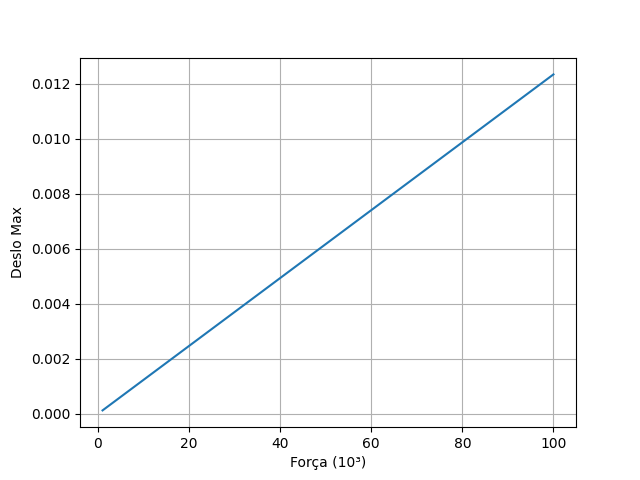

In [4]:
plt.plot(range(1,101), deslocs)
plt.xlabel("Força (10³)")
plt.ylabel("Deslo Max")
plt.grid(True)
plt.show()

In [5]:
def coordenadas_deformadas(connects, u_global, escala=10):
    c_def = []

    for no in range(len(connects)):
        x,y = connects[no]

        desloc_x = u_global[2*no]
        desloc_y = u_global[2*no+1]

        c_def.append((x + escala*desloc_x, y + escala*desloc_y))

    return c_def

In [6]:
def desenha_trelica(coords, bars, ax, color="black"):
    for no1, no2, _ in bars:
        x1, y1 = coords[no1]
        x2, y2 = coords[no2]
        ax.plot(
            [x1, x2],
            [y1, y2],
            color = color
        )

    ax.set_aspect('equal')
    ax.grid(True)
    

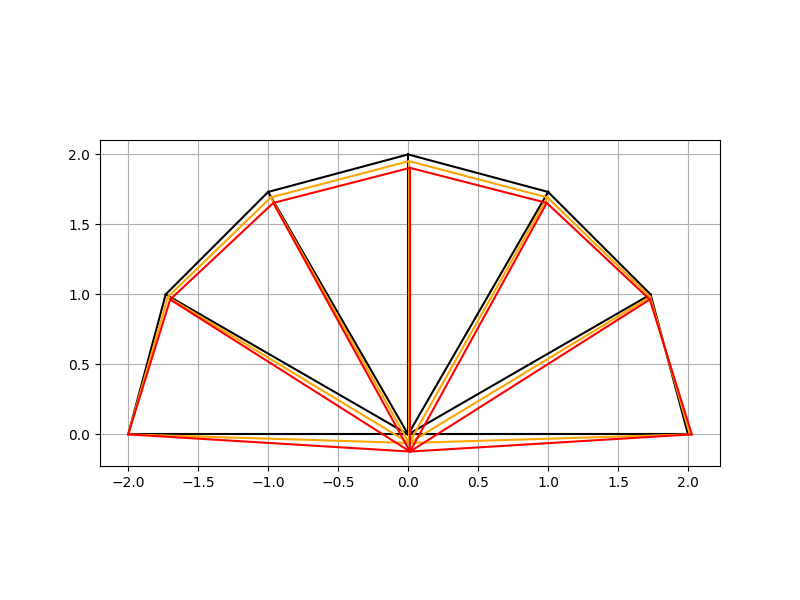

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

desenha_trelica(connects, bars, ax)
desenha_trelica(coordenadas_deformadas(connects, solucoes[50-1], 10), bars, ax, "orange")
desenha_trelica(coordenadas_deformadas(connects, solucoes[100-1], 10), bars, ax, "red")

plt.show()

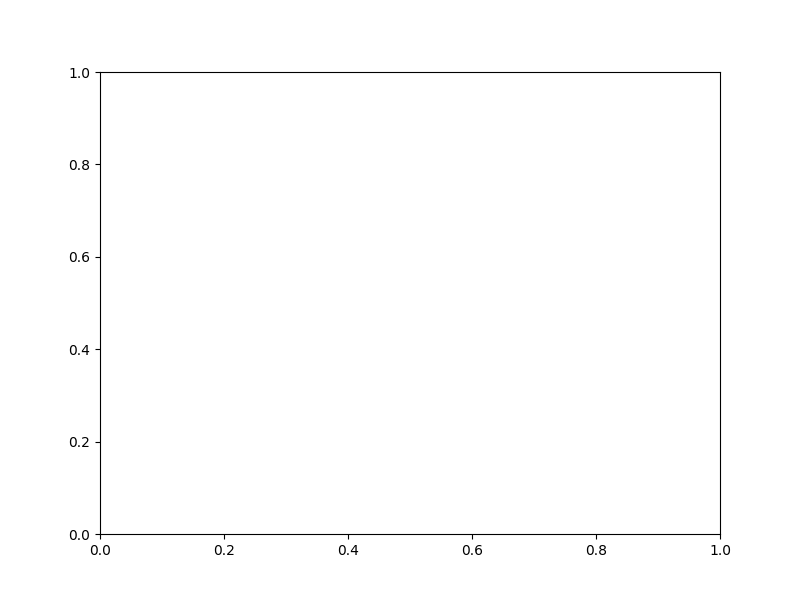

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

def update(frame, connects, solucoes):
    ax.clear()

    print(frame)
    u = solucoes[frame]
    c_def = coordenadas_deformadas(connects, u, 20)
    
    desenha_trelica(c_def, bars, ax)

    ax.set_ylim(-2, r+2)
    ax.set_title(f"F = {frame+1} 10³ N")
    ax.legend()


ani = FuncAnimation(
    fig,
    update,
    frames=len(solucoes),
    fargs=(connects, solucoes),
    interval=100,
    repeat_delay=500,
    repeat=True
)

plt.show()